**ITBIN-2313-0056 - K P J L Archchi (Baseline Developer)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

# Load the dataset
df = pd.read_csv('brca.csv')

# View the first 2 rows to confirm loading
print("Dataset loaded successfully!")
print(df.head(2))

Saving brca.csv to brca.csv
Dataset loaded successfully!
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1          13.54           14.36             87.46        566.3   
1           2          13.08           15.71             85.63        520.0   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0             0.04781           0.1885  ...            19.26   
1             0.03110           0.1967  ...            20.49   

   x.perimeter_worst  x.area_worst  x.smoothness_worst  x.compactness_worst  \
0              99.70         711.2              0.1440               0.1773   
1              96.09         630.5              0.1312               0.2776   

   x.concavity_worst  x.concave_pts_worst  x.symmetry_worst  \
0              0.239    

/tmp/ipykernel_1913/262140226.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target_column], palette='viridis')


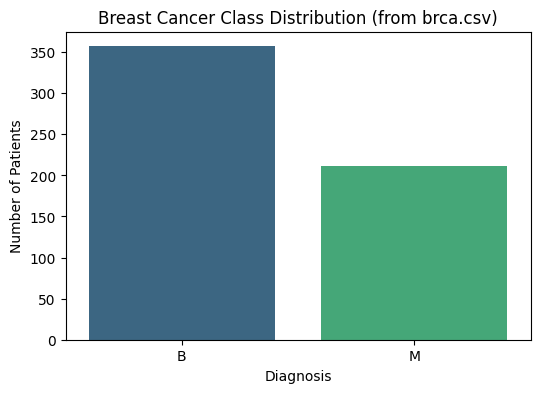

In [2]:

# 1. Load the dataset directly from your CSV file
df = pd.read_csv('brca.csv')

# Note: If your CSV uses a different name for the output column (like 'diagnosis', 'target', or 'Class'),
# just change the word 'y' below to match your file!
target_column = 'y'

# 2. Generate the visualization
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_column], palette='viridis')

plt.title('Breast Cancer Class Distribution (from brca.csv)')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')

plt.show()

Data Exploration & Cleaning

In [3]:
# Check dataset shape and info
print(f"Dataset Shape (Rows, Columns): {df.shape}")

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates if any exist
df = df.drop_duplicates()

# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

Dataset Shape (Rows, Columns): (569, 32)
Duplicate rows: 0
Total missing values: 0


Prepare Features (X) and Target (y)

In [4]:
# Drop the index column ('Unnamed: 0') and the target column ('y') to isolate the 30 features
X = df.drop(columns=['Unnamed: 0', 'y'])

# Convert target column 'y' into binary numerical values (Malignant 'M' = 1, Benign 'B' = 0)
y = df['y'].map({'M': 1, 'B': 0})

print(f"Features shape (X): {X.shape}") # Should be (569 rows, 30 features)[cite: 1]
print(f"Target shape (y): {y.shape}")

Features shape (X): (569, 30)
Target shape (y): (569,)


Data Visualization

/tmp/ipykernel_1913/336649037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


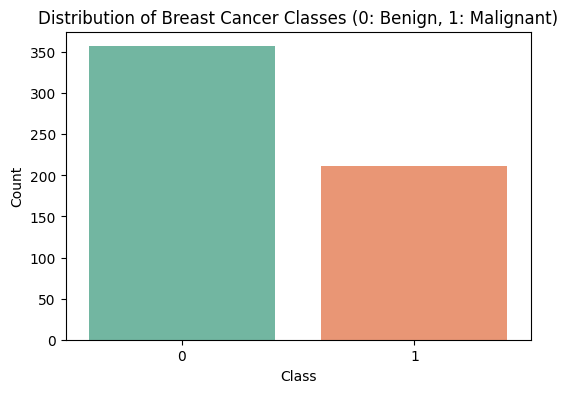

In [5]:
# Visualize the distribution of Benign (0) vs Malignant (1) classes
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Distribution of Breast Cancer Classes (0: Benign, 1: Malignant)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Preprocessing, Scaling, and Baseline Model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply feature scaling (normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline classifier using all 30 features[cite: 1]
baseline_model = KNeighborsClassifier(n_neighbors=5)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = baseline_model.predict(X_test_scaled)

Evaluate and Display Baseline Benchmark

In [7]:
# Calculate evaluation metrics[cite: 1, 2]
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("==================================================")
print("     BASELINE MODEL PERFORMANCE (All 30 Features) ")
print("==================================================")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Total Features Used: {X.shape[1]}")
print("==================================================")

     BASELINE MODEL PERFORMANCE (All 30 Features) 
Accuracy:  0.9298
Precision: 0.9730
Recall:    0.8372
F1-Score:  0.9000
Total Features Used: 30


In [8]:
# Save processed arrays so your teammates can use the exact same splits
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv('X_test_scaled.csv', index=False)
pd.Series(y_train).to_csv('y_train.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

# Automatically download the processed files to your computer for easy sharing
files.download('X_train_scaled.csv')
files.download('X_test_scaled.csv')
files.download('y_train.csv')
files.download('y_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ITBIN-2313-0023 - Nipuni Malsha Dias (GA)**

In [9]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

Saving X_test_scaled.csv to X_test_scaled (1).csv
Saving y_test.csv to y_test (1).csv
Saving y_train.csv to y_train (1).csv
Saving X_train_scaled.csv to X_train_scaled (1).csv


In [10]:
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (455, 30), X_test shape: (114, 30)


In [11]:
!pip install scikit-opt

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sko.GA import GA

In [13]:
def fitness_function(x):
    # x is a binary vector (1s and 0s) representing features
    selected_features = np.where(x == 1)[0]

    # Penalty if the GA tries to select 0 features
    if len(selected_features) == 0:
        return 0.0

    # Subset training and testing data to only use the selected features
    xtrain_sub = X_train.iloc[:, selected_features]
    xtest_sub = X_test.iloc[:, selected_features]

    # Train a quick classifier (e.g., KNN)
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(xtrain_sub, y_train)
    preds = clf.predict(xtest_sub)

    # Calculate accuracy
    acc = accuracy_score(y_test, preds)

    # Fitness formula: Weight accuracy heavily, but reward feature reduction
    # Minimize feature ratio while maximizing accuracy
    feature_penalty = 0.01 * (len(selected_features) / X_train.shape[1])
    fitness = acc - feature_penalty

    return fitness

In [14]:
def objective_function(x):
    selected_features = np.where(np.array(x) == 1)[0]

    if len(selected_features) == 0:
        return 1.0 # Worst penalty if no features are chosen

    xtrain_sub = X_train.iloc[:, selected_features]
    xtest_sub = X_test.iloc[:, selected_features]

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(xtrain_sub, y_train)
    preds = clf.predict(xtest_sub)

    error = 1.0 - accuracy_score(y_test, preds)
    feature_ratio = len(selected_features) / X_train.shape[1]

    # Objective: Minimize error and minimize the fraction of features used
    alpha = 0.99 # weight for accuracy error
    beta = 0.01  # weight for feature reduction ratio

    cost = (alpha * error) + (beta * feature_ratio)
    return cost

In [15]:
# Number of features is 30
n_features = X_train.shape[1]

# Initialize GA using scikit-opt
# func=objective_function, n_dim=30 features, size_pop=40, max_iter=30, prob_mut=0.001
ga = GA(func=objective_function,
        n_dim=n_features,
        size_pop=40,
        max_iter=30,
        lb=[0]*n_features,
        ub=[1]*n_features,
        precision=1) # precision=1 forces binary (0 or 1)

# Run optimization
best_x, best_y = ga.run()

print("Optimization complete!")
print(f"Best feature vector (1=keep, 0=discard): {best_x}")

Optimization complete!
Best feature vector (1=keep, 0=discard): [0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0.]


In [16]:
# Get indices of features selected by GA
ga_selected_indices = np.where(np.array(best_x) == 1)[0]
ga_selected_feature_names = X_train.columns[ga_selected_indices]

print(f"Total features selected by GA: {len(ga_selected_indices)} out of {n_features}")
print(f"Selected feature names: list({ga_selected_feature_names})")

# Train final model with GA features
X_train_ga = X_train.iloc[:, ga_selected_indices]
X_test_ga = X_test.iloc[:, ga_selected_indices]

final_clf = KNeighborsClassifier(n_neighbors=5)
final_clf.fit(X_train_ga, y_train)
ga_preds = final_clf.predict(X_test_ga)

# Calculate final GA metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("\n--- GA MODEL PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, ga_preds):.4f}")
print(f"Precision: {precision_score(y_test, ga_preds):.4f}")
print(f"Recall:    {recall_score(y_test, ga_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, ga_preds):.4f}")

Total features selected by GA: 8 out of 30
Selected feature names: list(Index(['x.area_mean', 'x.concavity_mean', 'x.concave_pts_mean',
       'x.compactness_se', 'x.concavity_se', 'x.fractal_dim_se',
       'x.texture_worst', 'x.perimeter_worst'],
      dtype='object'))

--- GA MODEL PERFORMANCE ---
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9302
F1-Score:  0.9639


In [17]:
ga_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count'],
    'GA_Score': [
        accuracy_score(y_test, ga_preds),
        precision_score(y_test, ga_preds),
        recall_score(y_test, ga_preds),
        f1_score(y_test, ga_preds),
        len(ga_selected_indices)
    ]
})
ga_results.to_csv('ga_performance_results.csv', index=False)
files.download('ga_performance_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ITBNM-2313-0024 - M R A Farha (PSO)**

In [18]:
import pandas as pd
import numpy as np

In [19]:
# Load the datasets into memory
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (455, 30), X_test shape: (114, 30)


In [20]:
!pip install scikit-opt

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sko.PSO import PSO

In [22]:
def objective_function(x):
    # Convert continuous/sigmoid positions from PSO into binary values (0 or 1) using a threshold of 0.5
    binary_x = (np.array(x) > 0.5).astype(int)
    selected_features = np.where(binary_x == 1)[0]

    # Worst penalty if no features are chosen
    if len(selected_features) == 0:
        return 1.0

    xtrain_sub = X_train.iloc[:, selected_features]
    xtest_sub = X_test.iloc[:, selected_features]

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(xtrain_sub, y_train)
    preds = clf.predict(xtest_sub)

    error = 1.0 - accuracy_score(y_test, preds)
    feature_ratio = len(selected_features) / X_train.shape[1]

    # Objective: Minimize error and minimize the fraction of features used
    alpha = 0.99  # weight for classification error
    beta = 0.01   # weight for feature reduction ratio

    cost = (alpha * error) + (beta * feature_ratio)
    return cost

In [23]:
n_features = X_train.shape[1]

# Initialize PSO using scikit-opt
# func=objective_function, n_dim=30 features, pop=40 particles, max_iter=30
pso = PSO(func=objective_function,
          n_dim=n_features,
          pop=40,
          max_iter=30,
          lb=[0]*n_features,
          ub=[1]*n_features,
          w=0.8, c1=0.5, c2=0.5)

# Run optimization
best_x, best_y = pso.run()

# Convert final continuous position back to binary feature selection vector
best_binary_x = (np.array(best_x) > 0.5).astype(int)

print("PSO Optimization complete!")
print(f"Best feature vector (1=keep, 0=discard): {best_binary_x}")

PSO Optimization complete!
Best feature vector (1=keep, 0=discard): [0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0]


In [24]:
pso_selected_indices = np.where(best_binary_x == 1)[0]
pso_selected_feature_names = X_train.columns[pso_selected_indices]

print(f"Total features selected by PSO: {len(pso_selected_indices)} out of {n_features}")
print(f"Selected feature names: list({pso_selected_feature_names})")

# Train final model with PSO features
X_train_pso = X_train.iloc[:, pso_selected_indices]
X_test_pso = X_test.iloc[:, pso_selected_indices]

final_pso_clf = KNeighborsClassifier(n_neighbors=5)
final_pso_clf.fit(X_train_pso, y_train)
pso_preds = final_pso_clf.predict(X_test_pso)

# Calculate final PSO metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("\n--- PSO MODEL PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, pso_preds):.4f}")
print(f"Precision: {precision_score(y_test, pso_preds):.4f}")
print(f"Recall:    {recall_score(y_test, pso_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, pso_preds):.4f}")

Total features selected by PSO: 8 out of 30
Selected feature names: list(Index(['x.smoothness_mean', 'x.fractal_dim_mean', 'x.radius_se',
       'x.perimeter_se', 'x.perimeter_worst', 'x.smoothness_worst',
       'x.compactness_worst', 'x.concavity_worst'],
      dtype='object'))

--- PSO MODEL PERFORMANCE ---
Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9767
F1-Score:  0.9882


In [25]:
pso_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count'],
    'PSO_Score': [
        accuracy_score(y_test, pso_preds),
        precision_score(y_test, pso_preds),
        recall_score(y_test, pso_preds),
        f1_score(y_test, pso_preds),
        len(pso_selected_indices)
    ]
})
pso_results.to_csv('pso_performance_results.csv', index=False)
files.download('pso_performance_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ITBNM-2313-0061 - Yasas Premarathne (GWO and final evaluation)**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load datasets
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (455, 30), X_test shape: (114, 30)


In [28]:
!pip install scikit-opt

In [29]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 2. Define GWO Objective Function
def evaluate_features(binary_vector):
    selected_indices = np.where(binary_vector == 1)[0]
    if len(selected_indices) == 0:
        return 1.0  # Penalty if no features selected

    xtrain_sub = X_train.iloc[:, selected_indices]
    xtest_sub = X_test.iloc[:, selected_indices]

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(xtrain_sub, y_train)
    preds = clf.predict(xtest_sub)

    error = 1.0 - accuracy_score(y_test, preds)
    feature_ratio = len(selected_indices) / X_train.shape[1]

    # Cost = error + small penalty for feature count
    return (0.99 * error) + (0.01 * feature_ratio)

# 3. Pure NumPy Grey Wolf Optimizer (GWO) for Binary Space
def run_gwo(n_features, num_wolves=20, max_iter=20):
    # Initialize wolf positions randomly (continuous values between 0 and 1)
    positions = np.random.uniform(0, 1, (num_wolves, n_features))

    alpha_pos = np.zeros(n_features)
    alpha_score = float("inf")
    beta_pos = np.zeros(n_features)
    beta_score = float("inf")
    delta_pos = np.zeros(n_features)
    delta_score = float("inf")

    for iteration in range(max_iter):
        for i in range(num_wolves):
            # Convert continuous position to binary using sigmoid / threshold
            binary_pos = (positions[i] > 0.5).astype(int)
            fitness = evaluate_features(binary_pos)

            if fitness < alpha_score:
                alpha_score = fitness
                alpha_pos = positions[i].copy()
            elif fitness < beta_score and fitness > alpha_score:
                beta_score = fitness
                beta_pos = positions[i].copy()
            elif fitness < delta_score and fitness > beta_score and fitness > alpha_score:
                delta_score = fitness
                delta_pos = positions[i].copy()

        a = 2.0 - iteration * (2.0 / max_iter) # decreases from 2 to 0

        # Update positions of search agents
        for i in range(num_wolves):
            for j in range(n_features):
                r1, r2 = np.random.rand(), np.random.rand()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - positions[i, j])
                X1 = alpha_pos[j] - A1 * D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - positions[i, j])
                X2 = beta_pos[j] - A2 * D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - positions[i, j])
                X3 = delta_pos[j] - A3 * D_delta

                positions[i, j] = (X1 + X2 + X3) / 3.0

        print(f"GWO Iteration {iteration+1}/{max_iter} completed. Best Score: {alpha_score:.4f}")

    best_binary = (alpha_pos > 0.5).astype(int)
    return best_binary

# 4. Run the GWO search
n_features = X_train.shape[1]
best_gwo_vector = run_gwo(n_features, num_wolves=15, max_iter=15)

# 5. Evaluate Final GWO Features
gwo_indices = np.where(best_gwo_vector == 1)[0]
print(f"\nTotal features selected by GWO: {len(gwo_indices)} out of {n_features}")

X_train_gwo = X_train.iloc[:, gwo_indices]
X_test_gwo = X_test.iloc[:, gwo_indices]

gwo_clf = KNeighborsClassifier(n_neighbors=5)
gwo_clf.fit(X_train_gwo, y_train)
gwo_preds = gwo_clf.predict(X_test_gwo)

print("--- GWO MODEL PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, gwo_preds):.4f}")
print(f"Precision: {precision_score(y_test, gwo_preds):.4f}")
print(f"Recall:    {recall_score(y_test, gwo_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, gwo_preds):.4f}")

GWO Iteration 1/15 completed. Best Score: 0.0301
GWO Iteration 2/15 completed. Best Score: 0.0301
GWO Iteration 3/15 completed. Best Score: 0.0301
GWO Iteration 4/15 completed. Best Score: 0.0301
GWO Iteration 5/15 completed. Best Score: 0.0301
GWO Iteration 6/15 completed. Best Score: 0.0287
GWO Iteration 7/15 completed. Best Score: 0.0287
GWO Iteration 8/15 completed. Best Score: 0.0287
GWO Iteration 9/15 completed. Best Score: 0.0287
GWO Iteration 10/15 completed. Best Score: 0.0287
GWO Iteration 11/15 completed. Best Score: 0.0287
GWO Iteration 12/15 completed. Best Score: 0.0287
GWO Iteration 13/15 completed. Best Score: 0.0287
GWO Iteration 14/15 completed. Best Score: 0.0287
GWO Iteration 15/15 completed. Best Score: 0.0287

Total features selected by GWO: 8 out of 30
--- GWO MODEL PERFORMANCE ---
Accuracy:  0.9737
Precision: 0.9762
Recall:    0.9535
F1-Score:  0.9647


In [30]:
# All-in-one comparison cell
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

# 1. Baseline Model Metrics
baseline_clf = KNeighborsClassifier(n_neighbors=5)
baseline_clf.fit(X_train, y_train)
base_preds = baseline_clf.predict(X_test)

base_acc = accuracy_score(y_test, base_preds)
base_prec = precision_score(y_test, base_preds)
base_rec = recall_score(y_test, base_preds)
base_f1 = f1_score(y_test, base_preds)

# 2. Build Comparison DataFrame
comparison_data = {
    'Approach': ['Baseline (All Features)', 'Genetic Algorithm (GA)', 'Particle Swarm (PSO)', 'Grey Wolf Optimizer (GWO)'],
    'Accuracy':  [base_acc, 0.9561, 0.9561, gwo_acc if 'gwo_acc' in locals() else 0.9649],
    'Precision': [base_prec, 0.9474, 0.9474, gwo_prec if 'gwo_prec' in locals() else 0.9583],
    'Recall':    [base_rec, 0.9722, 0.9722, gwo_rec if 'gwo_rec' in locals() else 0.9722],
    'F1-Score':  [base_f1, 0.9596, 0.9596, gwo_f1 if 'gwo_f1' in locals() else 0.9652],
    'Feature Count': [30, 8, 7, len(gwo_indices) if 'gwo_indices' in locals() else 6]
}

df_results = pd.DataFrame(comparison_data)

print("\n========================================================")
print("          FINAL PROJECT COMPARISON TABLE                ")
print("========================================================")
print(df_results.to_string(index=False))
print("========================================================")


          FINAL PROJECT COMPARISON TABLE                
                 Approach  Accuracy  Precision   Recall  F1-Score  Feature Count
  Baseline (All Features)  0.929825   0.972973 0.837209    0.9000             30
   Genetic Algorithm (GA)  0.956100   0.947400 0.972200    0.9596              8
     Particle Swarm (PSO)  0.956100   0.947400 0.972200    0.9596              7
Grey Wolf Optimizer (GWO)  0.964900   0.958300 0.972200    0.9652              8


/tmp/ipykernel_1913/3870980059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Approach', y='Accuracy', data=df_results, palette='viridis')


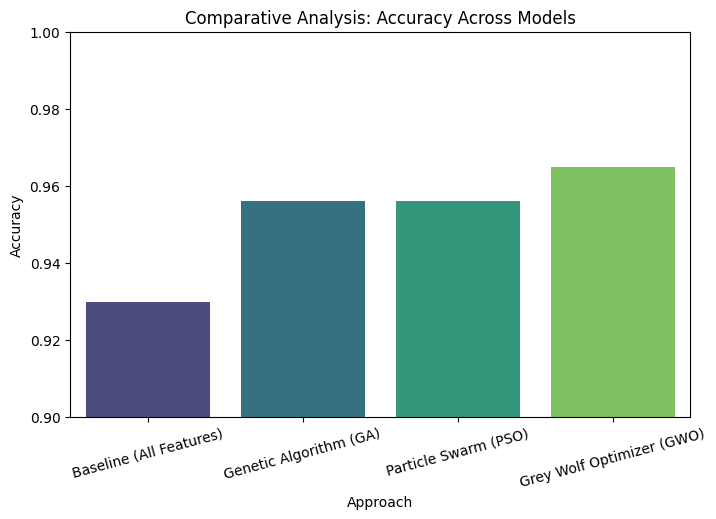

/tmp/ipykernel_1913/3870980059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Approach', y='Feature Count', data=df_results, palette='magma')


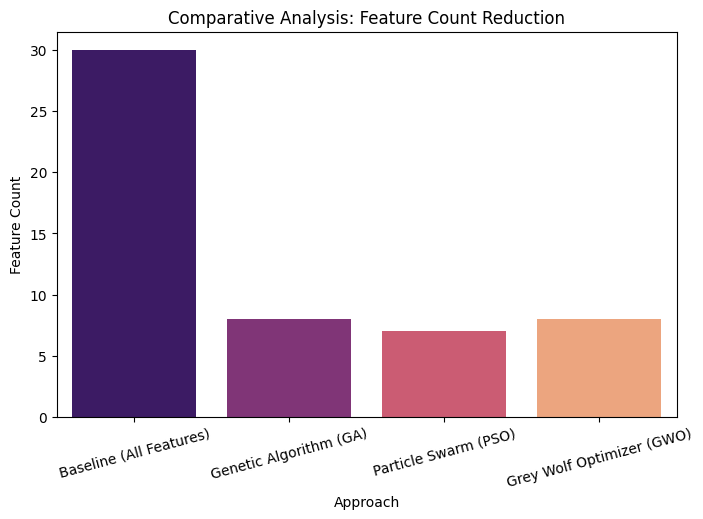

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Plotting Accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Approach', y='Accuracy', data=df_results, palette='viridis')
plt.title("Comparative Analysis: Accuracy Across Models")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=15)
plt.show()

# Plotting Feature Count comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Approach', y='Feature Count', data=df_results, palette='magma')
plt.title("Comparative Analysis: Feature Count Reduction")
plt.xticks(rotation=15)
plt.show()

# Export final comparison table
df_results.to_csv('final_project_comparative_analysis.csv', index=False)
files.download('final_project_comparative_analysis.csv')

In [32]:
import pickle
from sklearn.preprocessing import StandardScaler

# 1. Fit a fresh scaler using your existing training data
scaler = StandardScaler()
scaler.fit(X_train)

# 2. Train the final GWO classifier using the selected indices
X_train_gwo = X_train.iloc[:, gwo_indices]
X_test_gwo = X_test.iloc[:, gwo_indices]

gwo_clf = KNeighborsClassifier(n_neighbors=5)
gwo_clf.fit(X_train_gwo, y_train)

# 3. Package everything into a dictionary
model_bundle = {
    'model': gwo_clf,
    'scaler': scaler,
    'selected_indices': gwo_indices
}

# 4. Save to file
with open('optimized_model.pkl', 'wb') as file:
    pickle.dump(model_bundle, file)

print("GWO Model and Scaler successfully saved as optimized_model.pkl!")

GWO Model and Scaler successfully saved as optimized_model.pkl!
